# Day 34: Agent Handoffs

Day 33's supervisor called agents as tools. Today agents hand off to **each other** directly — no middleman.

## Install

In [ ]:
%pip install langgraph langchain-google-genai langchain --quiet

## Setup

In [22]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.tools import tool

load_dotenv(dotenv_path='../.env')
os.environ["GOOGLE_API_KEY"] = os.environ["GEMINI_API_KEY2"]

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
print("\u2705 Model ready")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


✅ Model ready


## Define Transfer Tools

Each agent gets a tool to hand off to the other. The LLM decides when to use it.

In [23]:
@tool
def transfer_to_sales() -> str:
    """Transfer to sales agent for pricing, plans, or purchase questions."""
    return "Transferring to sales..."

@tool
def transfer_to_support() -> str:
    """Transfer to support agent for technical issues or troubleshooting."""
    return "Transferring to support..."

support_model = model.bind_tools([transfer_to_sales])
sales_model = model.bind_tools([transfer_to_support])
print("\u2705 Transfer tools defined")

✅ Transfer tools defined


## Build Agent Nodes

Each node calls the LLM with its own system prompt. If the LLM calls a transfer tool, the node returns `Command(goto=...)` to hand off.

In [24]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langchain_core.messages import ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command

class State(TypedDict):
    messages: Annotated[list, add_messages]

SUPPORT_PROMPT = (
    "You are a tech support agent. Help with technical issues, bugs, and troubleshooting. "
    "If the user asks about pricing, plans, or purchasing, call transfer_to_sales. "
    "Keep answers short (2-3 sentences)."
)

SALES_PROMPT = (
    "You are a sales agent. Help with pricing, plans, and purchases. "
    "If the user asks about technical issues or bugs, call transfer_to_support. "
    "Keep answers short (2-3 sentences)."
)

In [25]:
def support_node(state: State) -> Command[Literal["sales_agent", "__end__"]]:
    messages = [SystemMessage(content=SUPPORT_PROMPT)] + state["messages"]
    response = support_model.invoke(messages)
    if response.tool_calls:
        call = response.tool_calls[0]
        return Command(
            goto="sales_agent",
            update={"messages": [
                response,
                ToolMessage(content="Transferred to sales agent.", tool_call_id=call["id"])
            ]}
        )
    return Command(goto="__end__", update={"messages": [response]})

def sales_node(state: State) -> Command[Literal["support_agent", "__end__"]]:
    messages = [SystemMessage(content=SALES_PROMPT)] + state["messages"]
    response = sales_model.invoke(messages)
    if response.tool_calls:
        call = response.tool_calls[0]
        return Command(
            goto="support_agent",
            update={"messages": [
                response,
                ToolMessage(content="Transferred to support agent.", tool_call_id=call["id"])
            ]}
        )
    return Command(goto="__end__", update={"messages": [response]})

print("\u2705 Agent nodes defined")

✅ Agent nodes defined


## Build Graph

In [26]:
builder = StateGraph(State)
builder.add_node("support_agent", support_node)
builder.add_node("sales_agent", sales_node)
builder.add_edge(START, "support_agent")

graph = builder.compile()
print("\u2705 Handoff graph compiled")

✅ Handoff graph compiled


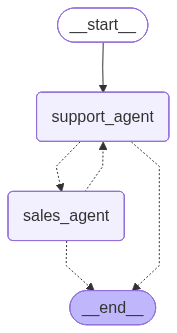

In [27]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Test: Support Handles Directly

A technical question — support answers without transferring.

In [28]:
result = graph.invoke({"messages": [{"role": "user", "content": "My app keeps crashing on startup."}]})

for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

My app keeps crashing on startup.
================================== Ai Message ==================================

[{'type': 'text', 'text': "I'm sorry to hear your app is crashing. Please try reinstalling the app and clearing its cache. If the issue persists, let me know what device and operating system you are using.", 'extras': {'signature': 'Cp4DAQw51seaw8Yl5MwAUisOkdPQWdRPj7XgKvCqWt1tmdSg5zZURmAker37Wy8VeyAzlCC7axMyLBrRsBkXlMGSs97PEN0e0kjC7aMtIIHDerRHLgW1iSDlqNJR71GE5BRfFsy94uEUawTrdOy4l04yGdk2t+8ZWqoh+3VT2846aL368ZXGB1PbQqD1mSaz+BIOAmmZYZFYYuWmc7BVk+/SKHqNOykgWqJr+A8X9ZrPaxdzpXQkFhqDAldTwoeJax7v2xmNuGuyOiZ+EAkjkXj0X8vQlSlIeZxKxDraZFy4/rP3DOAD/1Q7yaPxKR9VxM9BM6yuN9NQGRFdKUWtEPKAr/9yM2WFDgx+/ixnsjfjicLXsU424ZziYlxymNQVHOZqfrTSNTVxzqG75njYjvbcF3j6CVGQCgXlFTd6vOvNuMk+JFL7OblfB2PtieC0di0aygwD7WuYM1IMXIne5XFqbPnj8zpSOYGQUsi6VsrOxPISRCTPuIr4tX/ezlQQGsOqj7MXQNLWbjMuQP4OXqQqG88OBVtOyIHDsyEOyurU'}}]


## Test: Support Transfers to Sales

A pricing question — support should hand off to sales.

In [29]:
result = graph.invoke({"messages": [{"role": "user", "content": "How much does the pro plan cost?"}]})

for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

How much does the pro plan cost?
================================== Ai Message ==================================
Tool Calls:
  transfer_to_sales (bb114e9f-d894-4e9a-be94-74020cc83121)
 Call ID: bb114e9f-d894-4e9a-be94-74020cc83121
  Args:
================================= Tool Message =================================

Transferred to sales agent.
================================== Ai Message ==================================

Our sales team can provide you with the most up-to-date pricing information for the Pro plan. I'm transferring you to a sales agent now.


## Key Takeaways

1. **`Command(goto="node_name")`** lets an agent hand off control to another agent — no supervisor needed
2. Each agent **decides for itself** when to transfer — the LLM calls a transfer tool, the node returns a `Command`
3. **Day 33 = centralized** (supervisor calls agents), **Day 34 = peer-to-peer** (agents call each other)